# # Vasicek Interest rate model

In [40]:
import numpy as np
import matplotlib.pyplot as plt

In [154]:
#Weiner Process calculation.

def weiner_proc(sigma, dt, N):
    
    out = np.zeros(N)
    
    out[0] = sigma*np.sqrt(dt)*np.random.normal(0,1)
    
    for j in range(1, N):
        out[j] = out[j-1] + sigma*np.sqrt(dt)*np.random.normal(0,1)

    return out

#weiner_proc(0.1,1, 10)

* dr = theta x (lt_mean - rate) x dt + sigma x dw where dw = sqrt(dt) x norm.s.inv(rand())
* Interet rates can be negative, theta is rate of mena reversion to long-term mean. 
* It is one-factor model, which consoders short-rates and assumes long term rates are proportional to short rates


In [155]:
def vasicek_model(theta, lt_mean, sigma, dt, N, rate):
    
    out = np.zeros(N)
    out[0] = rate
    
    w = weiner_proc(sigma, dt, N)
    
    for j in range(1,N):
        out[j] = out[j-1] + (theta*(lt_mean - out[j-1])*dt)+w[j]
        
    return out

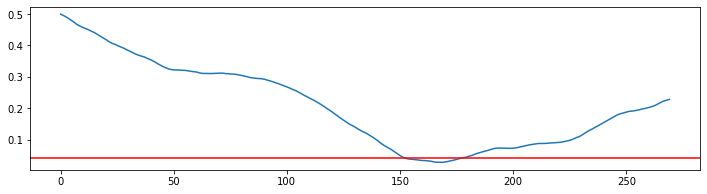

In [272]:
o = vasicek_model(10, 0.4, 0.01, 1/270, 270, 0.5)

figure, ax = plt.subplots(figsize = (12,3))
ax.plot(o)
ax.axhline(lt_mean, color='r')
plt.show()

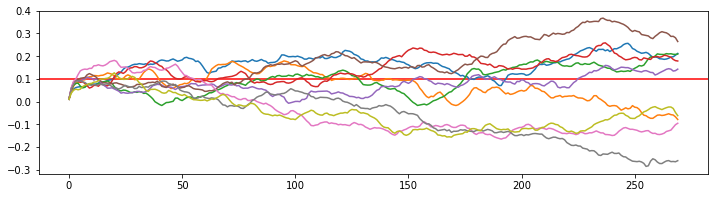

In [278]:
lt_mean = 0.1

figure, ax = plt.subplots(figsize = (12,3))

ax.axhline(lt_mean, color='r')

for i in range(1, 10):
    
    o = vasicek_model(50, lt_mean, 0.05, 0.01, 270, 0.01)
    ax.plot(o)

plt.show()

# Cox-Ingersoll-Ross CIR Model

* dr = theta x (lt_mean - rate) x dt + sigma x sqrt(rate) x dW
* volatility is stochastic in nature instead of constant based on rate
* Interest rates here can not be negative like in prev. model

In [256]:
def CIR_model(theta, lt_mean, sigma, dt, N, rate):
    
    out = np.zeros(N)
    out[0] = rate
    
    w = weiner_proc(sigma, dt, N)
    
    for j in range(1,N):
        out[j] = out[j-1] + (theta*(lt_mean - out[j-1])*dt)+w[j]*np.sqrt(out[j-i])
        
    return out

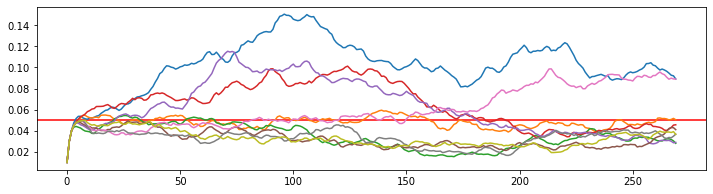

In [282]:
lt_mean = 0.05
figure, ax = plt.subplots(figsize = (12,3))

ax.axhline(lt_mean, color='r')

for i in range(1, 10):
    
    o = CIR_model(50,lt_mean, 0.05, 0.01, 270, 0.01)
    ax.plot(o)

plt.show()